## ___PC Analyses of fine root traits___
----------------------------------------------

In [1]:
!python --version

Python 3.14.0


The system cannot find the path specified.


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import pearsonr
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA, FactorAnalysis
from sklearn.preprocessing import StandardScaler

In [7]:
# lookup https://scikit-learn.org/stable/auto_examples/decomposition/plot_varimax_fa.html for varimax rotation

In [8]:
# a demo using the Iris dataset
iris = load_iris()
data, target, feature_names = iris.get("data"), iris.get("target"), iris.get("feature_names")
data_scaled = StandardScaler().fit_transform(data) # normalize the values

iris_model = PCA(n_components=2).fit(data)
comps = iris_model.transform(data)

iris_model_scaled = PCA(n_components=2).fit(data_scaled)
comps_scaled = iris_model_scaled.transform(data_scaled)

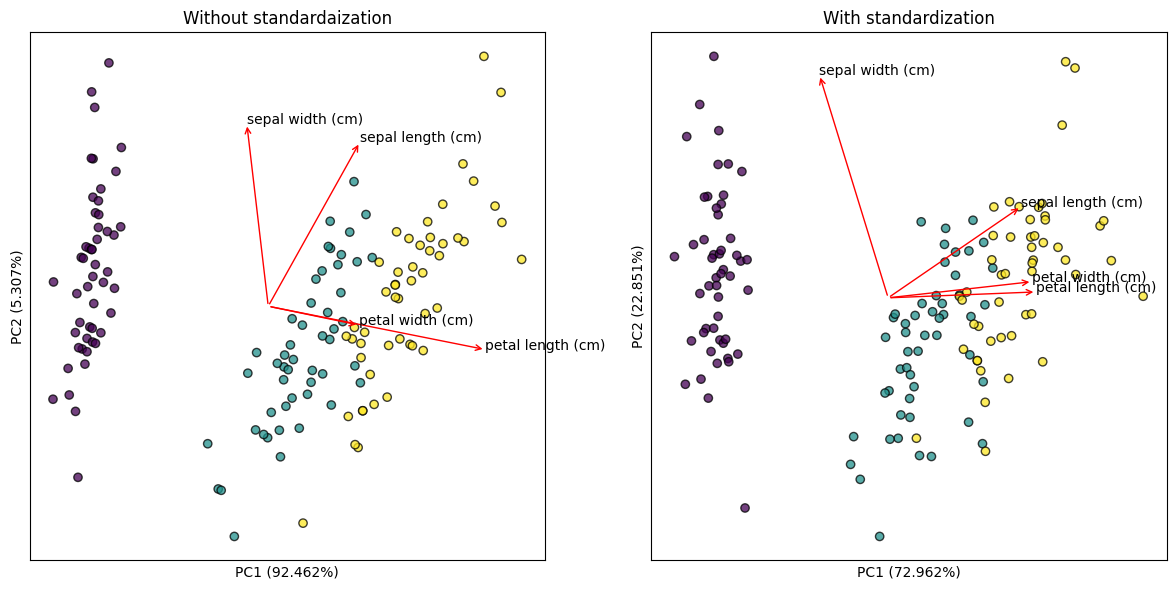

In [9]:
fig, axes = plt.subplots(ncols=2)
fig.set_size_inches(12, 6)
plt.rcParams["font.size"] = 10

for (ax, proj, model, title) in zip(axes, (comps, comps_scaled), (iris_model, iris_model_scaled), ("Without standardaization", "With standardization")):
    ax.scatter(x=proj[:, 0], y=proj[:, 1], edgecolor="black", c=target, alpha=0.75)
    for (label, (dx, dy)) in zip(feature_names, np.abs(proj).max(axis=0) * model.components_.T):
        ax.annotate(text='', xytext=(0, 0), xy=(dx, dy), arrowprops={"arrowstyle": "->", "color": "red"})
        ax.text(x=dx, y=dy, s=label)
    ax.set_xlabel(f"PC1 ({model.explained_variance_ratio_[0]*100:.3f}%)")
    ax.set_ylabel(f"PC2 ({model.explained_variance_ratio_[1]*100:.3f}%)")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(title)

plt.tight_layout()
plt.show()

In [70]:
data.head()

,F00679,F00727,F00261,F00709,F00056,F00645,F01286,F01287,F01289,F01290
0,0.142951,447.167648,18.478265,0.169294,1.0,NaN,Populus,trichocarpa,Salicaceae,Malpighiales
1,0.249630,166.388374,14.456530,0.160036,2.0,NaN,Populus,trichocarpa,Salicaceae,Malpighiales
2,0.425085,60.723679,10.760881,0.171351,3.0,NaN,Populus,trichocarpa,Salicaceae,Malpighiales
3,0.175513,330.424588,22.065220,0.169294,1.0,NaN,Populus,tremula,Salicaceae,Malpighiales
4,0.285828,116.664475,16.304355,0.160041,2.0,NaN,Populus,tremula,Salicaceae,Malpighiales


In [11]:
model = PCA(n_components=2) # we go from 4 traits to 2 PCA axes
projections = model.fit_transform(data.loc[:, CHOSEN_RES_TRAITS])

In [12]:
projections

array([[402.39899468,  -5.66887285],
       [121.59500872,  -4.3192284 ],
       [ 15.87888104,  -5.99269038],
       ...,
       [ -7.72459231,   9.99896645],
       [ 45.3221649 ,   6.58473206],
       [ 27.03060129,  -0.64127104]], shape=(603, 2))

In [13]:
data.F00056.value_counts(dropna=False)

F00056
1.0    294
3.0    157
2.0    152
Name: count, dtype: int64

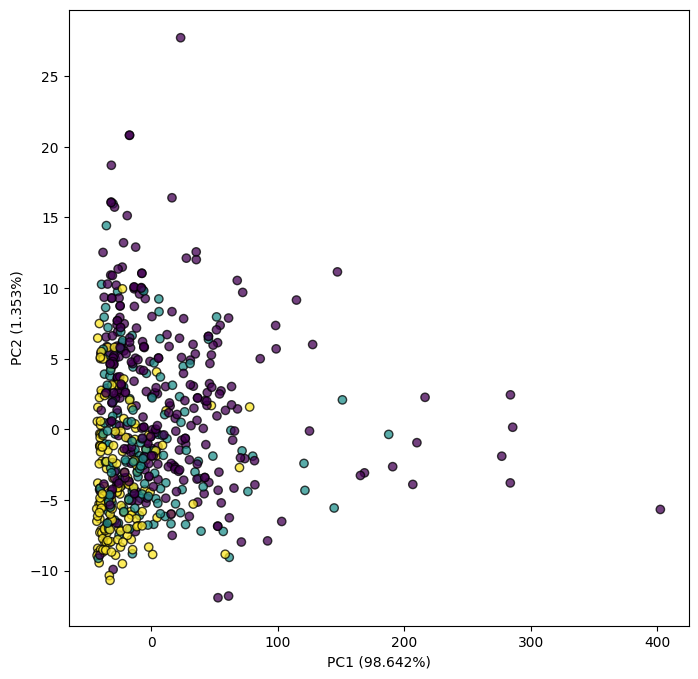

In [14]:
fig, axes = plt.subplots()
fig.set_size_inches(8, 8)
axes.scatter(x=projections[:, 0], y=projections[:, 1], edgecolor="black", c=data.F00056.fillna(value=4), alpha=0.75)
# colour the data points by root order, replace nas with 4
             
axes.set_xlabel(f"PC1 ({model.explained_variance_ratio_[0]*100:.3f}%)")
axes.set_ylabel(f"PC2 ({model.explained_variance_ratio_[1]*100:.3f}%)")
plt.show()

In [75]:
# PCA loadings, coordination of the features
model.components_.T

array([[-2.81914088e-03,  3.09104042e-03],
       [ 9.99812934e-01, -1.91252249e-02],
       [ 1.91307063e-02,  9.99755259e-01],
       [-4.06038888e-04, -1.06814251e-02]])

In [76]:
# proportions of the variance explained by the 2 axes
model.explained_variance_

array([2450.80362   ,   33.61302414])

In [77]:
model.explained_variance_ratio_

array([0.98642302, 0.01352889])

In [78]:
model.explained_variance_ / model.explained_variance_.sum() # pfff

array([0.98647046, 0.01352954])

In [79]:
CHOSEN_RES_TRAITS, model.mean_

(['F00679', 'F00727', 'F00261', 'F00709'],
 array([ 0.44442477, 44.73307527, 16.45082039,  0.33428621]))

In [80]:
# maximum absolute values of points on each axes
np.abs(projections).max(axis=0)

array([402.39899468,  27.72236154])

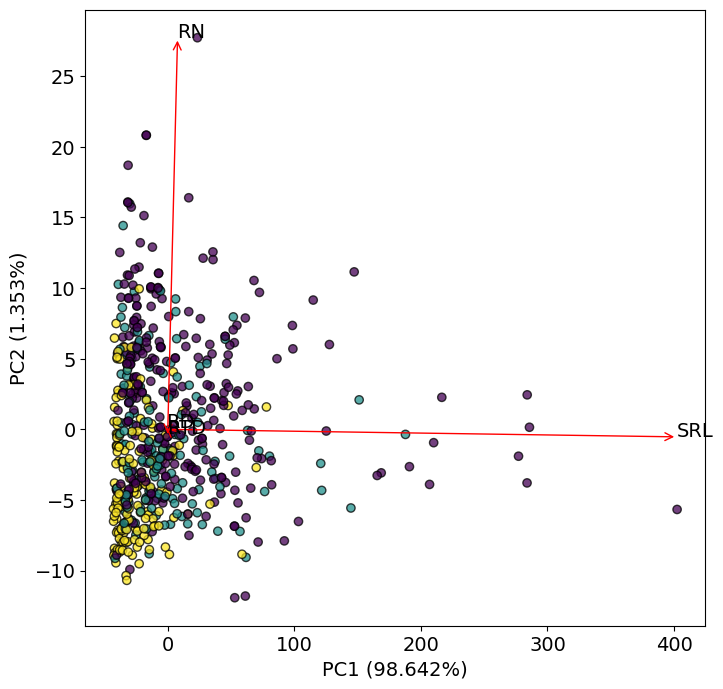

In [81]:
# WITHOUT SCALING

fig, axes = plt.subplots()
fig.set_size_inches(8, 8)
axes.scatter(x=projections[:, 0], y=projections[:, 1], edgecolor="black", c=data.F00056.fillna(value=4), alpha=0.75)
for (label, (dx, dy)) in zip(CHOSEN_RES_TRAITS_NAMES, np.abs(projections).max(axis=0) * model.components_.T):
    axes.annotate(text='', xytext=(0, 0), xy=(dx, dy), arrowprops={"arrowstyle": "->", "color": "red"})
    axes.text(x=dx, y=dy, s=label)
axes.set_xlabel(f"PC1 ({model.explained_variance_ratio_[0]*100:.3f}%)")
axes.set_ylabel(f"PC2 ({model.explained_variance_ratio_[1]*100:.3f}%)")
plt.show()

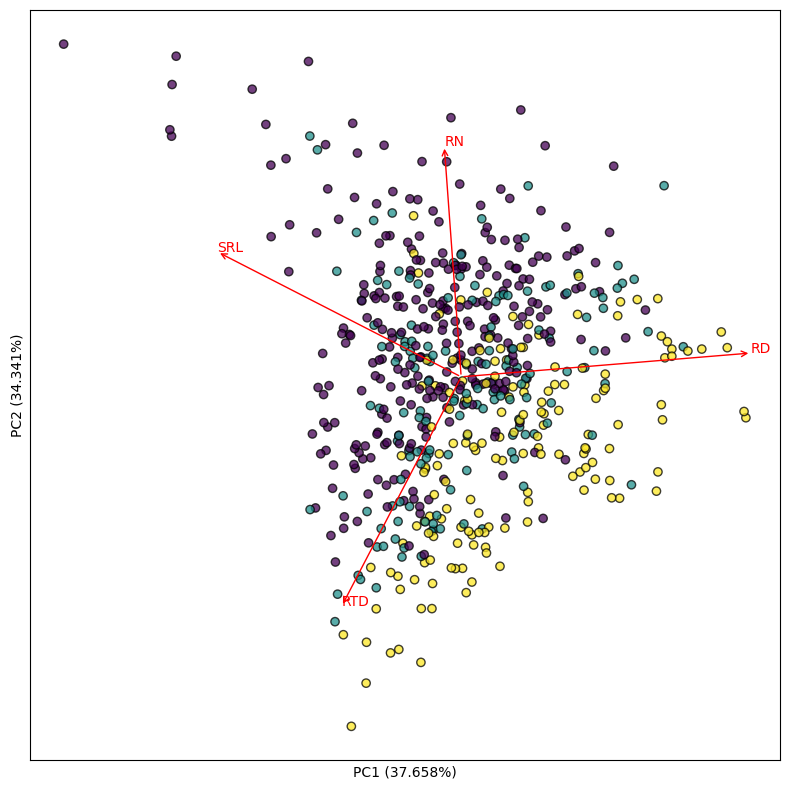

In [57]:
# WITH SCALING

scaled_data = StandardScaler().fit_transform(data.loc[:, CHOSEN_RES_TRAITS])
model = PCA(n_components=2).fit(scaled_data)
projections = model.transform(scaled_data)

fig, axes = plt.subplots()
fig.set_size_inches(8, 8)
axes.scatter(x=projections[:, 0], y=projections[:, 1], edgecolor="black", c=data.F00056, alpha=0.75)
for (label, (dx, dy)) in zip(CHOSEN_RES_TRAITS_NAMES, np.abs(projections).max(axis=0) * model.components_.T):
    axes.annotate(text='', xytext=(0, 0), xy=(dx, dy), arrowprops={"arrowstyle": "->", "color": "red"})
    axes.text(x=dx, y=dy, s=label, fontdict={"color": "red"})
axes.set_xlabel(f"PC1 ({model.explained_variance_ratio_[0]*100:.3f}%)")
axes.set_ylabel(f"PC2 ({model.explained_variance_ratio_[1]*100:.3f}%)")
axes.set_xticks([])
axes.set_yticks([])
plt.tight_layout()
plt.show()
# plt.savefig(fname=r"../plots/fred_4traits_pca.jpeg", format="jpeg", dpi=1000)

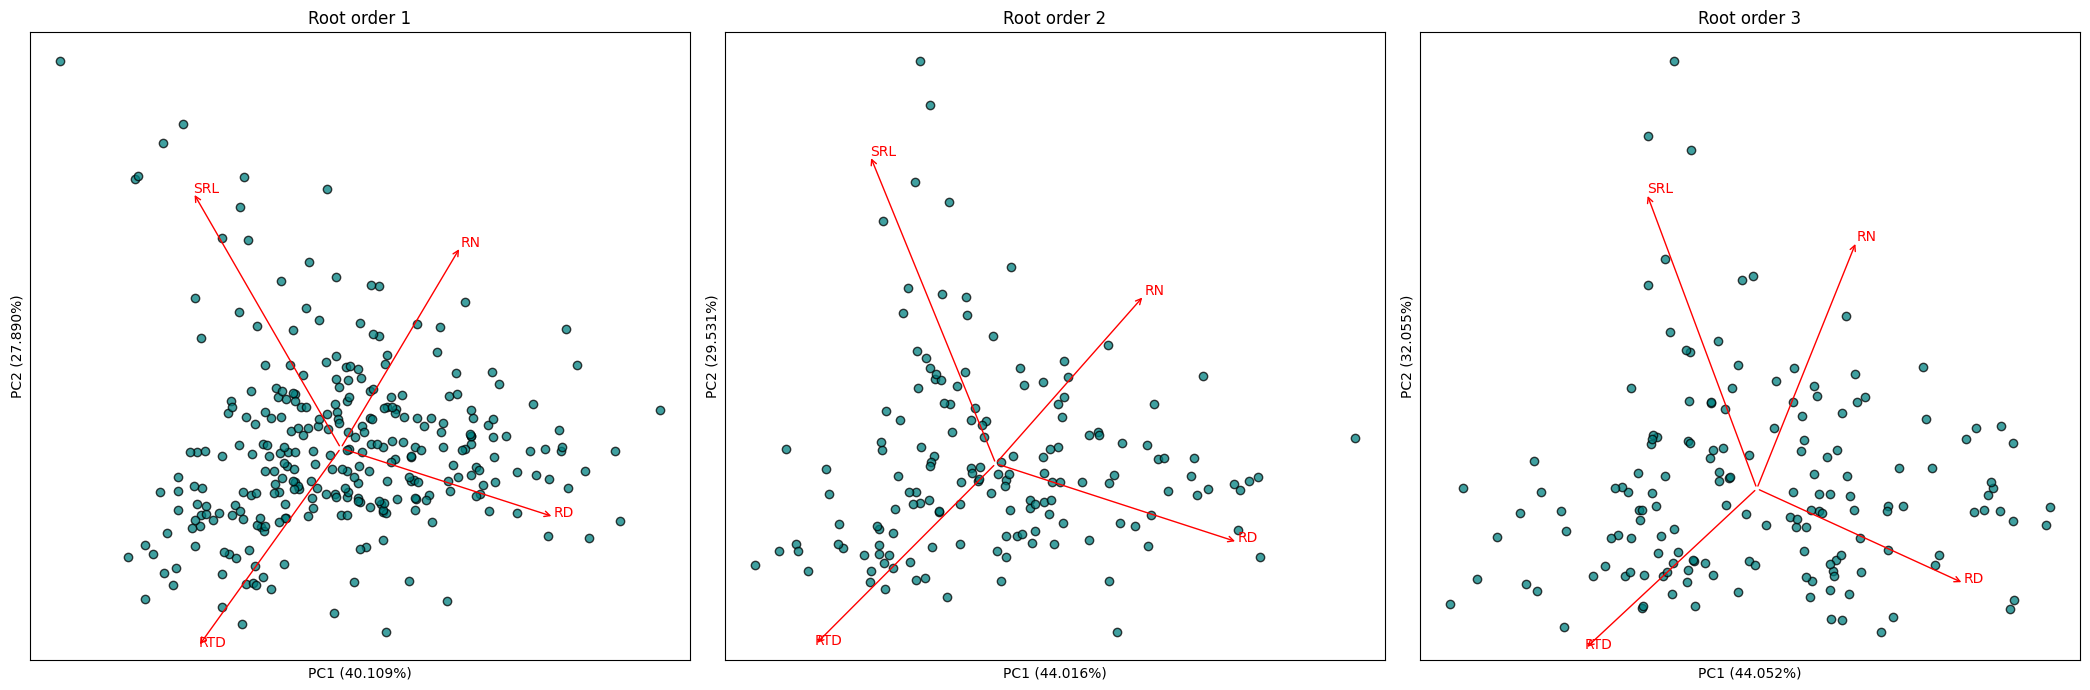

In [15]:
fig, axes = plt.subplots(ncols=3, nrows=1)
fig.set_size_inches(21, 7)

for (axis, (order, df)) in zip(axes.flatten(), data.groupby("F00056", dropna=False)):
    scaled_data = StandardScaler().fit_transform(df.loc[:, CHOSEN_RES_TRAITS])
    model = PCA(n_components=2).fit(scaled_data)
    projections = model.transform(scaled_data)
    
    axis.scatter(x=projections[:, 0], y=projections[:, 1], edgecolor="black", alpha=0.75, color="teal")
    axis.set_xlabel(f"PC1 ({model.explained_variance_ratio_[0]*100:.3f}%)")
    axis.set_ylabel(f"PC2 ({model.explained_variance_ratio_[1]*100:.3f}%)")
    axis.set_xticks([])
    axis.set_yticks([])
    try:
        axis.set_title(f"Root order {int(order)}")
    except ValueError:
        axis.set_title("Root order unknown")
    
    for (label, (dx, dy)) in zip(CHOSEN_RES_TRAITS_NAMES, np.abs(projections).max(axis=0) * model.components_.T):
        axis.annotate(text='', xytext=(0, 0), xy=(dx, dy), arrowprops={"arrowstyle": "->", "color": "red"})
        axis.text(x=dx, y=dy, s=label, fontdict={"color": "red"})
        

plt.tight_layout()
plt.show()
# plt.savefig(fname=r"../plots/pca_order_grouped.jpeg", format="jpeg", dpi=1000)

## ___Iris___
-------------------

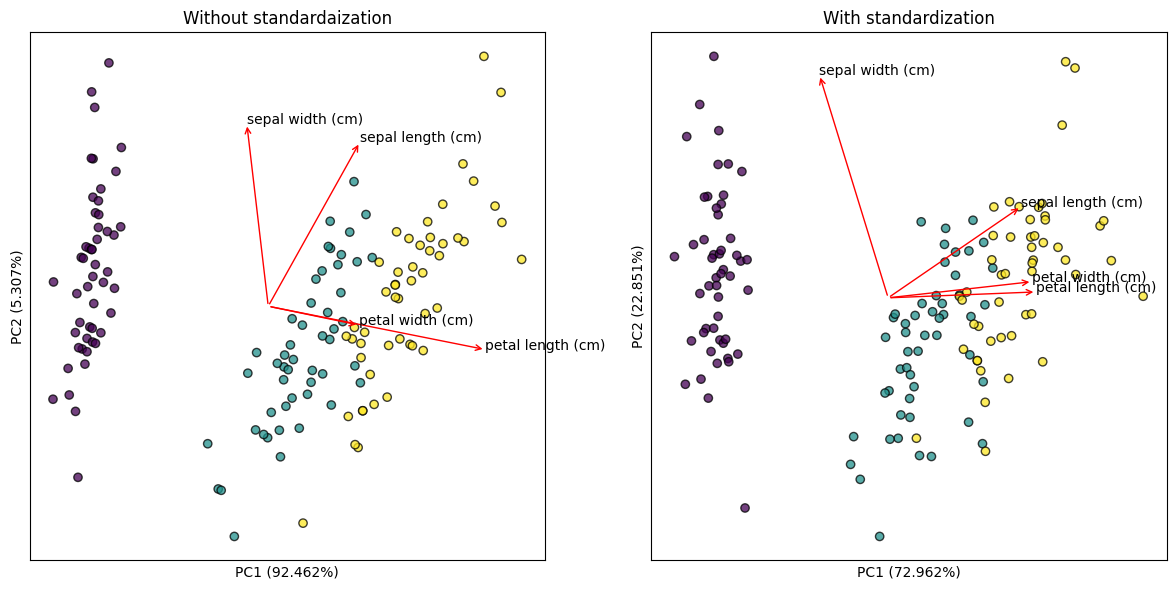

In [53]:
loadings

{1.0: array([[ 0.84766266, -0.18777859],
        [-0.58657196,  0.69834381],
        [ 0.47599497,  0.55023035],
        [-0.56626068, -0.54196755]]),
 2.0: array([[ 0.8968053 , -0.21269235],
        [-0.46574664,  0.83402129],
        [ 0.5499396 ,  0.45534071],
        [-0.6698522 , -0.49081924]]),
 3.0: array([[ 0.89725778, -0.25142611],
        [-0.47743478,  0.78423307],
        [ 0.43150184,  0.65672538],
        [-0.74443361, -0.42533809]]),
 nan: array([[-0.05860482,  0.96958441],
        [-0.81936076, -0.46231022],
        [-0.81103872,  0.28604859],
        [ 0.84110998, -0.10697775]])}

In [67]:
# multiindex
idx = pd.MultiIndex.from_tuples([(order, name) for order in loadings.keys() for name in CHOSEN_RES_TRAITS_NAMES])

In [70]:
loadings

{1.0: array([[ 0.84766266, -0.18777859],
        [-0.58657196,  0.69834381],
        [ 0.47599497,  0.55023035],
        [-0.56626068, -0.54196755]]),
 2.0: array([[ 0.8968053 , -0.21269235],
        [-0.46574664,  0.83402129],
        [ 0.5499396 ,  0.45534071],
        [-0.6698522 , -0.49081924]]),
 3.0: array([[ 0.89725778, -0.25142611],
        [-0.47743478,  0.78423307],
        [ 0.43150184,  0.65672538],
        [-0.74443361, -0.42533809]]),
 nan: array([[-0.05860482,  0.96958441],
        [-0.81936076, -0.46231022],
        [-0.81103872,  0.28604859],
        [ 0.84110998, -0.10697775]])}

In [49]:
# https://www.jcchouinard.com/pca-loadings/
# loadings_df = pd.DataFrame(data=np.array([(a, b) for _ in loadings.values() for (a, b) in _]), index=idx, columns=("PC1", "PC2"))
# loadings_df.to_csv(path_or_buf="../data/fred_pca.csv", na_rep="NA", float_format="%.4f")

--------------------
--------------------

In [50]:
# double check the PCA results with R
# data.rename(mapper={o: n for o, n in zip(CHOSEN_RES_TRAITS, CHOSEN_RES_TRAITS_NAMES)}, axis=1).to_csv(r"../data/fred_subset.csv", float_format="%.6f", na_rep="NA")

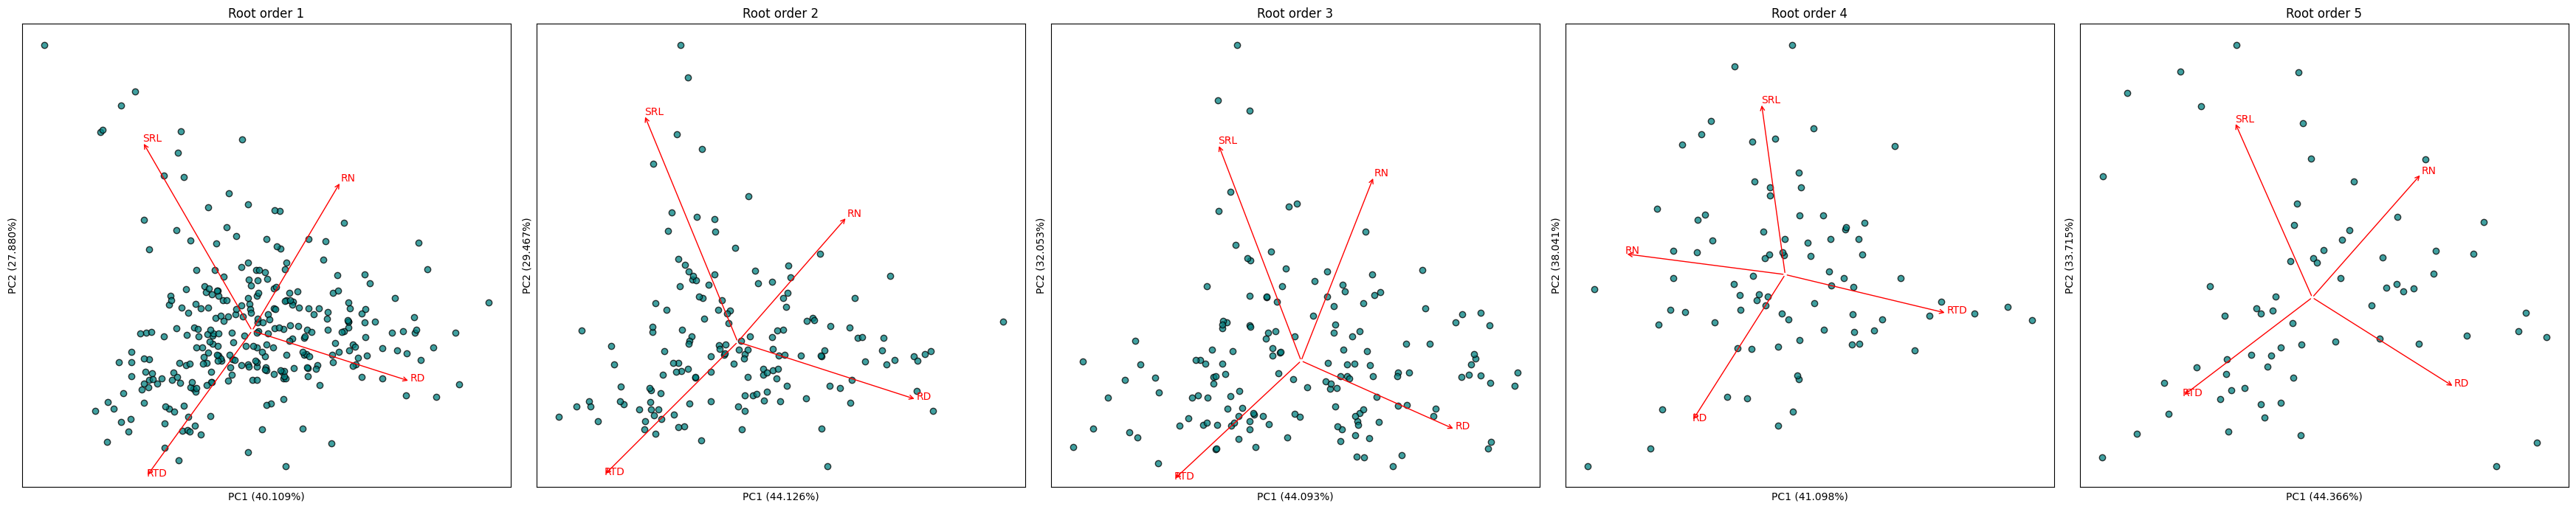

In [18]:
rord = fred.loc[:, CHOSEN_RES_TRAITS + ["F00056"]].dropna() # .isna().mean()

fig, axes = plt.subplots(ncols=5, nrows=1)
fig.set_size_inches(35, 7)

for (axis, (order, df)) in zip(axes.flatten(), rord.groupby("F00056", dropna=False)):
    scaled_rord = StandardScaler().fit_transform(df.loc[:, CHOSEN_RES_TRAITS])
    model = PCA(n_components=2).fit(scaled_rord)
    projections = model.transform(scaled_rord)
    
    axis.scatter(x=projections[:, 0], y=projections[:, 1], edgecolor="black", alpha=0.75, color="teal")
    axis.set_xlabel(f"PC1 ({model.explained_variance_ratio_[0]*100:.3f}%)")
    axis.set_ylabel(f"PC2 ({model.explained_variance_ratio_[1]*100:.3f}%)")
    axis.set_xticks([])
    axis.set_yticks([])
    axis.set_title(f"Root order {int(order)}")
    
    for (label, (dx, dy)) in zip(CHOSEN_RES_TRAITS_NAMES, np.abs(projections).max(axis=0) * model.components_.T):
        axis.annotate(text='', xytext=(0, 0), xy=(dx, dy), arrowprops={"arrowstyle": "->", "color": "red"})
        axis.text(x=dx, y=dy, s=label, fontdict={"color": "red"})
        

plt.tight_layout()
plt.show()
# plt.savefig(fname=r"../plots/pca_order_grouped.jpeg", format="jpeg", dpi=1000)

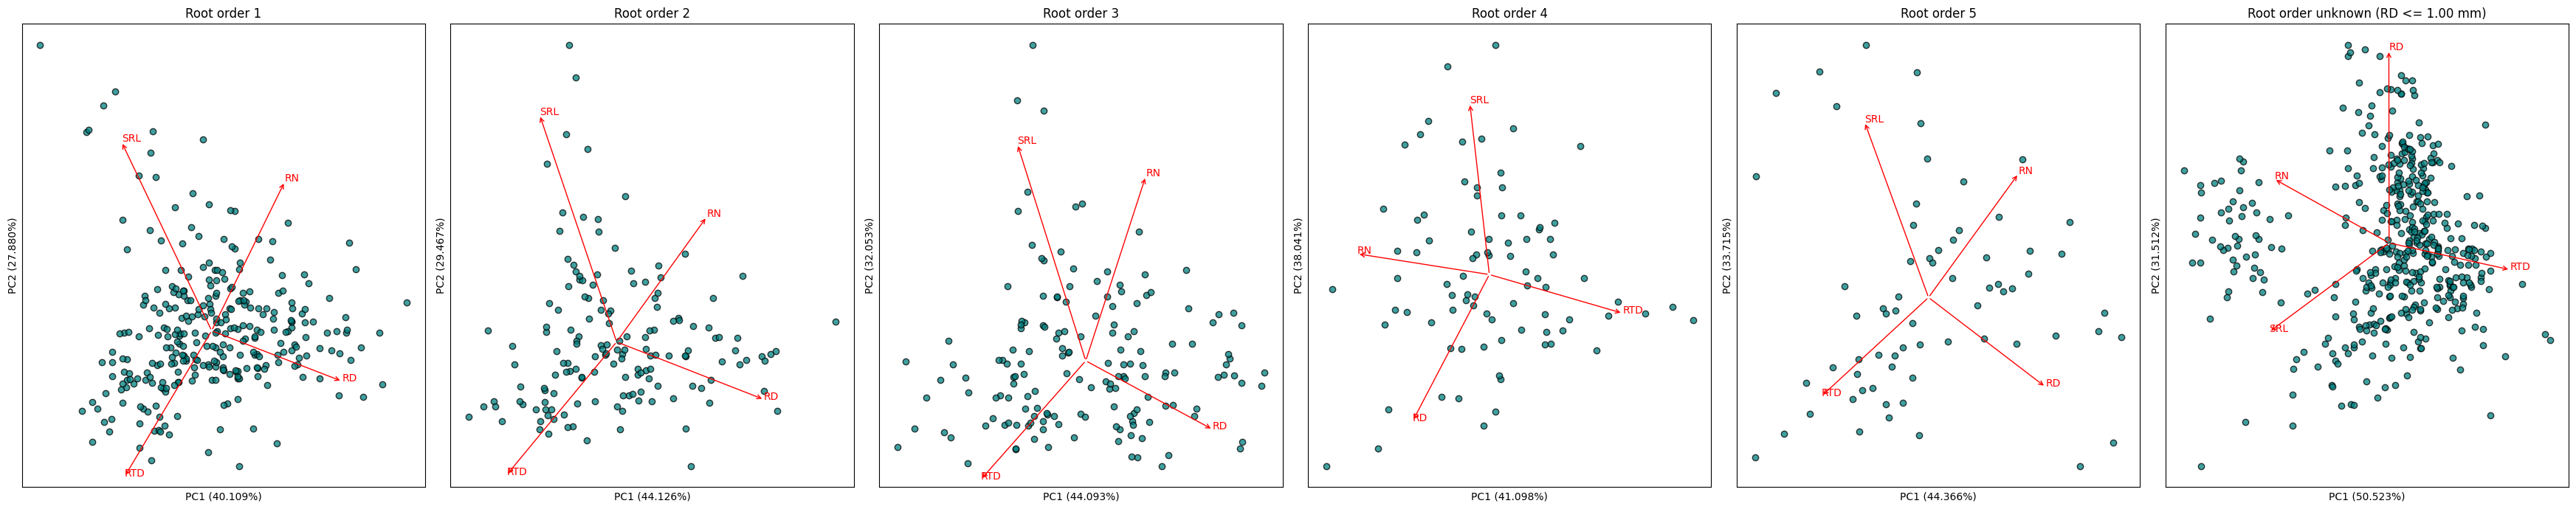

In [37]:
rord = fred.loc[:, CHOSEN_RES_TRAITS + ["F00056"]].dropna(subset=CHOSEN_RES_TRAITS).query("(not F00056.isna()) | (F00679 <= 1.00)")

fig, axes = plt.subplots(ncols=6, nrows=1)
fig.set_size_inches(35, 7)

for (axis, (order, df)) in zip(axes.flatten(), rord.groupby("F00056", dropna=False)):
    scaled_rord = StandardScaler().fit_transform(df.loc[:, CHOSEN_RES_TRAITS])
    model = PCA(n_components=2).fit(scaled_rord)
    projections = model.transform(scaled_rord)
    
    axis.scatter(x=projections[:, 0], y=projections[:, 1], edgecolor="black", alpha=0.75, color="teal")
    axis.set_xlabel(f"PC1 ({model.explained_variance_ratio_[0]*100:.3f}%)")
    axis.set_ylabel(f"PC2 ({model.explained_variance_ratio_[1]*100:.3f}%)")
    axis.set_xticks([])
    axis.set_yticks([])
    try:
        axis.set_title(f"Root order {int(order)}")
    except ValueError:
        axis.set_title(r"Root order unknown (RD <= 1.00 mm)")
    
    for (label, (dx, dy)) in zip(CHOSEN_RES_TRAITS_NAMES, np.abs(projections).max(axis=0) * model.components_.T):
        axis.annotate(text='', xytext=(0, 0), xy=(dx, dy), arrowprops={"arrowstyle": "->", "color": "red"})
        axis.text(x=dx, y=dy, s=label, fontdict={"color": "red"})
        

plt.tight_layout()
plt.show()

In [36]:
rord.loc[:, ["F00056", "F00679"]].groupby("F00056", dropna=False).max() # cool :)

,F00679
F00056,
1.0,1.2240
2.0,1.4270
3.0,1.7806
4.0,2.0650
5.0,3.3500
NaN,1.0000
